[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mlnjsh/rl-basics/blob/main/MDP_introduction.ipynb)

In [2]:
#%pip install --upgrade pygame
#%pip install "setuptools"

# A coding introduction to the Markov Decision Process



## The problem we are trying to solve

Before any algorithm, we need a **task**. Throughout this course the task is a small **maze**.

**The story.** A robot (drawn as a **fuchsia circle**) is placed in a 5x5 grid of rooms with walls between some of them. One corner is the **goal** (the green square). The robot can move **UP, RIGHT, DOWN, or LEFT**, but a wall blocks the move and the robot stays where it is. We want the robot to reach the goal in **as few steps as possible**.

**Why this is a Markov Decision Process (MDP).** Every reinforcement-learning task is described by five ingredients, and our maze has all of them:

| MDP ingredient | In our maze |
|---|---|
| **States** *s* | The square the robot is in, written as a pair *(row, col)* &mdash; so 25 states in total. |
| **Actions** *a* | The four moves: 0 = UP, 1 = RIGHT, 2 = DOWN, 3 = LEFT. |
| **Transitions** | Where a move takes the robot. Here it is *deterministic*: a legal move always succeeds, and a move into a wall leaves the robot where it was. |
| **Reward** *r* | **&minus;1 for every step** until the goal is reached. Fewer penalties means a shorter path. |
| **Goal / terminal state** | The bottom-right square. Reaching it **ends the episode**. |

**What "solving" means.** We want a **policy** &mdash; a rule that tells the robot which action to take in each square &mdash; that reaches the goal with the **largest total reward** (that is, the fewest steps). The rest of the course is a tour of different methods for *finding* that policy: starting from methods that need to know the maze rules in advance (dynamic programming), moving to methods that learn purely from trial-and-error experience (Monte-Carlo, SARSA, Q-Learning), and finally to deep neural networks.

This first notebook simply gets us comfortable with the **Gym interface** &mdash; the three methods `reset()`, `step()` and `render()` &mdash; that every later notebook reuses.

In [3]:
# @title Setup code (not important) - Run this cell by pressing "Shift + Enter"



!pip install -qq gym==0.23.0


from typing import Tuple, Dict, Optional, Iterable

import numpy as np
import matplotlib
from matplotlib import animation

from IPython.display import HTML

import gym
from gym import spaces
from gym.error import DependencyNotInstalled

import pygame
from pygame import gfxdraw

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pygame")

class Maze(gym.Env):

    def __init__(self, exploring_starts: bool = False,
                 shaped_rewards: bool = False, size: int = 5) -> None:
        super().__init__()
        self.exploring_starts = exploring_starts
        self.shaped_rewards = shaped_rewards
        self.state = (size - 1, size - 1)
        self.goal = (size - 1, size - 1)
        self.maze = self._create_maze(size=size)
        self.distances = self._compute_distances(self.goal, self.maze)
        self.action_space = spaces.Discrete(n=4)
        self.action_space.action_meanings = {0: 'UP', 1: 'RIGHT', 2: 'DOWN', 3: "LEFT"}
        self.observation_space = spaces.MultiDiscrete([size, size])

        self.screen = None
        self.agent_transform = None

    def step(self, action: int) -> Tuple[Tuple[int, int], float, bool, Dict]:
        reward = self.compute_reward(self.state, action)
        self.state = self._get_next_state(self.state, action)
        done = self.state == self.goal
        info = {}
        return self.state, reward, done, info

    def reset(self) -> Tuple[int, int]:
        if self.exploring_starts:
            while self.state == self.goal:
                self.state = tuple(self.observation_space.sample())
        else:
            self.state = (0, 0)
        return self.state

    def render(self, mode: str = 'human') -> Optional[np.ndarray]:
        assert mode in ['human', 'rgb_array']

        screen_size = 600
        scale = screen_size / 5

        if self.screen is None:
            pygame.init()
            self.screen = pygame.Surface((screen_size, screen_size))

        surf = pygame.Surface((screen_size, screen_size))
        surf.fill((22, 36, 71))


        for row in range(5):
            for col in range(5):

                state = (row, col)
                for next_state in [(row + 1, col), (row - 1, col), (row, col + 1), (row, col - 1)]:
                    if next_state not in self.maze[state]:

                        # Add the geometry of the edges and walls (i.e. the boundaries between
                        # adjacent squares that are not connected).
                        row_diff, col_diff = np.subtract(next_state, state)
                        left = (col + (col_diff > 0)) * scale - 2 * (col_diff != 0)
                        right = ((col + 1) - (col_diff < 0)) * scale + 2 * (col_diff != 0)
                        top = (5 - (row + (row_diff > 0))) * scale - 2 * (row_diff != 0)
                        bottom = (5 - ((row + 1) - (row_diff < 0))) * scale + 2 * (row_diff != 0)

                        gfxdraw.filled_polygon(surf, [(left, bottom), (left, top), (right, top), (right, bottom)], (255, 255, 255))

        # Add the geometry of the goal square to the viewer.
        left, right, top, bottom = scale * 4 + 10, scale * 5 - 10, scale - 10, 10
        gfxdraw.filled_polygon(surf, [(left, bottom), (left, top), (right, top), (right, bottom)], (40, 199, 172))

        # Add the geometry of the agent to the viewer.
        agent_row = int(screen_size - scale * (self.state[0] + .5))
        agent_col = int(scale * (self.state[1] + .5))
        gfxdraw.filled_circle(surf, agent_col, agent_row, int(scale * .6 / 2), (255, 0, 255))  # FUCHSIA agent

        surf = pygame.transform.flip(surf, False, True)
        self.screen.blit(surf, (0, 0))

        return np.transpose(
                np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2)
            )

    def close(self) -> None:
        if self.screen is not None:
            pygame.display.quit()
            pygame.quit()
            self.screen = None

    def compute_reward(self, state: Tuple[int, int], action: int) -> float:
        next_state = self._get_next_state(state, action)
        if self.shaped_rewards:
            return - (self.distances[next_state] / self.distances.max())
        return - float(state != self.goal)

    def simulate_step(self, state: Tuple[int, int], action: int):
        reward = self.compute_reward(state, action)
        next_state = self._get_next_state(state, action)
        done = next_state == self.goal
        info = {}
        return next_state, reward, done, info

    def _get_next_state(self, state: Tuple[int, int], action: int) -> Tuple[int, int]:
        if action == 0:
            next_state = (state[0] - 1, state[1])
        elif action == 1:
            next_state = (state[0], state[1] + 1)
        elif action == 2:
            next_state = (state[0] + 1, state[1])
        elif action == 3:
            next_state = (state[0], state[1] - 1)
        else:
            raise ValueError("Action value not supported:", action)
        if next_state in self.maze[state]:
            return next_state
        return state

    @staticmethod
    def _create_maze(size: int) -> Dict[Tuple[int, int], Iterable[Tuple[int, int]]]:
        maze = {(row, col): [(row - 1, col), (row + 1, col), (row, col - 1), (row, col + 1)]
                for row in range(size) for col in range(size)}

        left_edges = [[(row, 0), (row, -1)] for row in range(size)]
        right_edges = [[(row, size - 1), (row, size)] for row in range(size)]
        upper_edges = [[(0, col), (-1, col)] for col in range(size)]
        lower_edges = [[(size - 1, col), (size, col)] for col in range(size)]
        walls = [
            [(1, 0), (1, 1)], [(2, 0), (2, 1)], [(3, 0), (3, 1)],
            [(1, 1), (1, 2)], [(2, 1), (2, 2)], [(3, 1), (3, 2)],
            [(3, 1), (4, 1)], [(0, 2), (1, 2)], [(1, 2), (1, 3)],
            [(2, 2), (3, 2)], [(2, 3), (3, 3)], [(2, 4), (3, 4)],
            [(4, 2), (4, 3)], [(1, 3), (1, 4)], [(2, 3), (2, 4)],
        ]

        obstacles = upper_edges + lower_edges + left_edges + right_edges + walls

        for src, dst in obstacles:
            maze[src].remove(dst)

            if dst in maze:
                maze[dst].remove(src)

        return maze

    @staticmethod
    def _compute_distances(goal: Tuple[int, int],
                           maze: Dict[Tuple[int, int], Iterable[Tuple[int, int]]]) -> np.ndarray:
        distances = np.full((5, 5), np.inf)
        visited = set()
        distances[goal] = 0.

        while visited != set(maze):
            sorted_dst = [(v // 5, v % 5) for v in distances.argsort(axis=None)]
            closest = next(x for x in sorted_dst if x not in visited)
            visited.add(closest)

            for neighbour in maze[closest]:
                distances[neighbour] = min(distances[neighbour], distances[closest] + 1)
        return distances


def display_video(frames):
    # Copied from: https://colab.research.google.com/github/deepmind/dm_control/blob/master/tutorial.ipynb
    orig_backend = matplotlib.get_backend()
    matplotlib.use('Agg')
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    matplotlib.use(orig_backend)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])
    def update(frame):
        im.set_data(frame)
        return [im]
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                    interval=50, blit=True, repeat=False)
    return HTML(anim.to_html5_video())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.4/624.4 kB 10.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Quick view of the Gym library:
<br/>
<br/>

Gym is a library for reinforcement learning research. It provides us with a simple interface to a large number of tasks, including

- Classic control tasks (CartPole, Pendulum, MountainCar, etc)
- Classic video games (Space Invaders, Breakout, Pong, etc)
- Continuous control tasks
- Robotic arm manipulation

In this section we are going to get familiar with the five methods that we'll use while solving a control
task.


<br/>
<br/>


![title](https://github.com/escape-velocity-labs/beginner_master_rl/blob/main/img/mdp_diagram.svg?raw=1)

###### Source: https://upload.wikimedia.org/wikipedia/commons/1/1b/Reinforcement_learning_diagram.svg

##### Making the environment: Maze()

An **environment** is the world the agent lives in. It holds the current
situation (the *state*), accepts the agent's moves (the *actions*), and hands
back a *reward* plus the next state after each move.

In Gym you normally create an environment by passing its name to `gym.make`,
for example `gym.make('CartPole-v1')`. Here our Maze was defined in the setup
cell above, so we create it directly by calling `Maze()`. Either way we get a
`gym.Env` object that we will talk to through just three methods: `reset()`,
`step()` and `render()`.

In [4]:
# Gym gives us the reinforcement-learning environments (tasks) to solve.
import gym
# NumPy handles the numerical work: arrays, random choices, etc.
import numpy as np
# 'display' lets us refresh images inside the notebook.
from IPython import display
# Matplotlib is what we use to draw the maze pictures.
from matplotlib import pyplot as plt

# Tell the notebook to show the plots right here, under the code cell.
%matplotlib inline

In [5]:
# Build a fresh Maze environment. 'env' is the world the agent will act in.
env = Maze()

###### env.reset()

`reset()` starts a **new episode**. It puts the maze back to its starting
square and returns that square so the agent knows where it begins. Call this
once at the start of every episode, before taking any steps.

In [6]:
# reset() puts the maze back to the start and tells us the starting square.
initial_state = env.reset()
# Print that starting square so we can see where the episode begins.
print(f"The new episode will start in state: {initial_state}")

The new episode will start in state: (0, 0)


##### env.render()

`render()` draws the environment as it looks **right now**. With
`mode='rgb_array'` it returns the picture as a NumPy array of pixels, which we
can then display with Matplotlib. It is purely for our eyes; the agent does not
need it to learn.

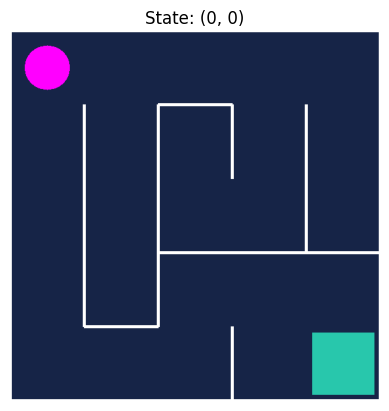

In [7]:
# render() returns a picture (an array of pixels) of the maze right now.
frame = env.render(mode='rgb_array')
# Hide the x/y axis numbers; they mean nothing for a maze picture.
plt.axis('off')
# Put the current state in the title so we know which square is shown.
plt.title(f"State: {initial_state}")
# Draw the picture in the notebook.
plt.imshow(frame)

##### env.step()

`step(action)` is the heart of the loop: it carries out the chosen **action**
and moves the world forward one tick. It hands back a tuple of four things:

- **next state** &mdash; the square the agent is in after the move.
- **reward** &mdash; the numerical feedback for that move (here always &minus;1 per step).
- **done** &mdash; `True` if the episode is finished (the goal was reached).
- **info** &mdash; an extra dictionary for any other details (often empty).

The basic interaction loop of all RL is simply: *observe state &rarr; choose
action &rarr; call `step` &rarr; repeat until `done`.*

In [8]:
# Choose action 2, which in this maze means "move down".
action = 2
# step() applies the action and returns: the new square, the reward,
# whether the episode is finished, and an extra-info dictionary.
next_state, reward, done, info = env.step(action)
# Show where the agent ended up after moving down.
print(f"After moving down 1 row, the agent is in state: {next_state}")
# Show the reward we got for that move (-1 for every step in this maze).
print(f"After moving down 1 row, we got a reward of: {reward}")
# Tell us whether that move reached the goal and ended the episode.
print("After moving down 1 row, the task is", "" if done else "not", "finished")

After moving down 1 row, the agent is in state: (1, 0)
After moving down 1 row, we got a reward of: -1.0
After moving down 1 row, the task is not finished


###### Render the new state

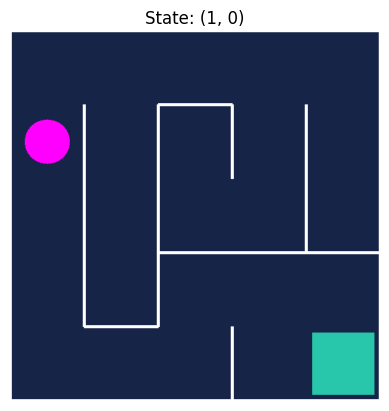

In [9]:
# Take a fresh picture of the maze now that the agent has moved.
frame = env.render(mode='rgb_array')
# Hide the axis numbers.
plt.axis('off')
# Title shows the new state after the step.
plt.title(f"State: {next_state}")
# Draw the updated maze.
plt.imshow(frame)

##### env.close()

`close()` ends the session and releases any resources the environment was
using (windows, drawing surfaces, and so on). Call it when you are finished
with an environment.

In [10]:
# close() shuts the environment down and frees the resources it used.
env.close()

## Maze environment: Find the exit.


In this section we are going to familiarize ourselves with the environment that we'll use in the lessons 2 (dynamic programming), 3 (Monte Carlo methods) and 4 (temporal difference methods). This environment is perfect for learning the basics of Reinforcement Learning because:

- It has few states (25)
- Transitions between states are deterministic ($p(s', r| s, a) = 1$)
- All rewards are the same (-1) until the episode concludes. Thus facilitating the study of the value and action-value functions

Through this environment, we are going to review the concepts seen in lesson 1 (The Markov decision process):

- States and state space
- Actions and action space
- Trajectories and episodes
- Rewards and returns
- Policy


The environment is a maze of 5x5 cells, in which the goal of the agent is to find the exit, located in the lower right corner, in the cell (4,4). In the image, the exit is colored in light green.

To reach the exit, the agent can take four different actions: move up, move down, move left and move right.

###### Create the environment.

In [11]:
# Create the maze environment again for the next set of experiments.
env = Maze()

##### States and state space

The states consist of a tuple of two integers, both in the range [0, 4], representing the row and column in which the agent is currently located:
<br>
<br>

\begin{equation}
    s = (row, column) \;\\
    row, column \in \{0,1,2,3, 4\}
\end{equation}
<br>
<br>
The state space (set of all possible states in the task) has 25 elements (all possible combinations of rows and columns):


\begin{equation}
    Rows \times Columns \;\\
    S = \{(0, 0), (0, 1), (1, 0), ...\}
\end{equation}

Information about the state space is stored in the env.observation_space property. In this environment, it is of MultiDiscrete([5 5]) type, which means that it consists of two elements (rows and columns), each with 5 different values.

In [12]:
# reset() returns the starting square; print it as an example state.
print(f"For example, the initial state is: {env.reset()}")
# observation_space describes every state the agent could ever see.
print(f"The space state is of type: {env.observation_space}")

For example, the initial state is: (0, 0)
The space state is of type: MultiDiscrete([5 5])


##### Actions and action space

In this environment, there are four different actions and they are represented by integers:

\begin{equation}
a \in \{0, 1, 2, 3\}
\end{equation}

- 0 -> move up
- 1 -> move right
- 2 -> move down
- 3 -> move left

To execute an action, simply pass it as an argument to the env.step method. Information about the action space is stored in the env.action_space property which is of Discrete(4) class. This means that in this case it only consists of an element in the range [0,4), unlike the state space seen above.


In [13]:
# action_space.sample() picks one legal action at random as an example.
print(f"An example of a valid action is: {env.action_space.sample()}")
# action_space describes all the moves the agent is allowed to make.
print(f"The action state is of type: {env.action_space}")

An example of a valid action is: 1
The action state is of type: Discrete(4)


##### Trajectories and episodes

A trajectory is the sequence generated by moving from one state to another (both arbitrary)

\begin{equation}
  \tau = S_0, A_0, R_1, S_1, A_1, ... R_N, S_N,
\end{equation}

Let's generate a trajectory of 3 moves in code:

In [14]:
# Start a fresh maze and reset it to the beginning.
env = Maze()
state = env.reset()
# We will collect the agent's experience here, one step per list entry.
trajectory = []
# Take three random moves to build a short trajectory.
for _ in range(3):
    # Pick a random action (the agent is not learning yet).
    action = env.action_space.sample()
    # Apply the action and read back the result.
    next_state, reward, done, extra_info = env.step(action)
    # Record this step as [where we were, what we did, the reward, finished?, where we landed].
    trajectory.append([state, action, reward, done, next_state])
    # The landing square becomes the current square for the next loop.
    state = next_state
# Close the environment when we are done.
env.close()

# Print the three-step trajectory we just collected.
print(f"Congrats! You just generated your first trajectory:\n{trajectory}")

Congrats! You just generated your first trajectory:
[[(0, 0), 0, -1.0, False, (0, 0)], [(0, 0), 2, -1.0, False, (1, 0)], [(1, 0), 2, -1.0, False, (2, 0)]]


An episode is a trajectory that goes from the initial state of the process to the final one:

\begin{equation}
  \tau = S_0, A_0, R_1, S_1, A_1, ... R_T, S_T,
\end{equation}
where T is the terminal state.

Let's generate a whole episode in code:

In [15]:
# Fresh maze, reset to the start.
env = Maze()
state = env.reset()
# This list will hold every step from start until the goal is reached.
episode = []
# 'done' becomes True only when the agent reaches the exit.
done = False
# Keep taking random moves until the episode finishes.
while not done:
    # Pick a random action.
    action = env.action_space.sample()
    # Apply it and read the outcome.
    next_state, reward, done, extra_info = env.step(action)
    # Save this step.
    episode.append([state, action, reward, done, next_state])
    # Move on: the new square is now the current one.
    state = next_state
# Free the environment.
env.close()

# Print the full episode (start -> exit) we generated.
print(f"Congrats! You just generated your first episode:\n{episode}")

Congrats! You just generated your first episode:
[[(0, 0), 1, -1.0, False, (0, 1)], [(0, 1), 2, -1.0, False, (1, 1)], [(1, 1), 3, -1.0, False, (1, 1)], [(1, 1), 1, -1.0, False, (1, 1)], [(1, 1), 2, -1.0, False, (2, 1)], [(2, 1), 3, -1.0, False, (2, 1)], [(2, 1), 0, -1.0, False, (1, 1)], [(1, 1), 0, -1.0, False, (0, 1)], [(0, 1), 3, -1.0, False, (0, 0)], [(0, 0), 3, -1.0, False, (0, 0)], [(0, 0), 2, -1.0, False, (1, 0)], [(1, 0), 0, -1.0, False, (0, 0)], [(0, 0), 3, -1.0, False, (0, 0)], [(0, 0), 2, -1.0, False, (1, 0)], [(1, 0), 0, -1.0, False, (0, 0)], [(0, 0), 3, -1.0, False, (0, 0)], [(0, 0), 1, -1.0, False, (0, 1)], [(0, 1), 1, -1.0, False, (0, 2)], [(0, 2), 0, -1.0, False, (0, 2)], [(0, 2), 1, -1.0, False, (0, 3)], [(0, 3), 3, -1.0, False, (0, 2)], [(0, 2), 0, -1.0, False, (0, 2)], [(0, 2), 0, -1.0, False, (0, 2)], [(0, 2), 1, -1.0, False, (0, 3)], [(0, 3), 2, -1.0, False, (1, 3)], [(1, 3), 3, -1.0, False, (1, 3)], [(1, 3), 2, -1.0, False, (2, 3)], [(2, 3), 1, -1.0, False, (2, 3)]

##### Rewards and returns

A reward is numerical feedback that the environment generates when the agent takes an action *a* in a state *s*:

\begin{equation}
    r = r(s, a)
\end{equation}

Let's generate a reward from the environment:

In [16]:
# Fresh maze, reset to the start.
env = Maze()
state = env.reset()
# Pick a single random action.
action = env.action_space.sample()
# Take that one step; we only care about the reward here, so we ignore the rest with _.
_, reward, _, _ = env.step(action)
# Show the reward earned by that action in that state.
print(f"We achieved a reward of {reward} by taking action {action} in state {state}")

We achieved a reward of -1.0 by taking action 0 in state (0, 0)


The return associated with a moment in time *t* is the sum (discounted) of rewards that the agent obtains from that moment. We are going to calculate $G_0$, that is, the return to the beginning of the episode:

\begin{equation}
    G_0 = R_1 + \gamma R_2 + \gamma^2 R_3 + ... + \gamma^{T-1} R_T
\end{equation}



Let's assume that the discount factor $\gamma = 0.99$:


In [17]:
# Fresh maze, reset to the start.
env = Maze()
state = env.reset()
# We will run a full episode, so start with 'not done'.
done = False
# Discount factor: rewards further in the future count a little less.
gamma = 0.99
# G_0 is the (discounted) total reward from the start of the episode.
G_0 = 0
# t counts the time step, used as the power of gamma.
t = 0
# Play random moves until we reach the exit.
while not done:
    # Random action.
    action = env.action_space.sample()
    # Take the step; we only need the reward and the done flag here.
    _, reward, done, _ = env.step(action)
    # Add this step's reward, discounted by gamma**t, into the return.
    G_0 += gamma ** t * reward
    # Advance the time step.
    t += 1
# Free the environment.
env.close()

# Report how many moves it took and the resulting return.
print(
    f"""It took us {t} moves to find the exit,
    and each reward r(s,a)=-1, so the return amounts to {G_0}""")

It took us 777 moves to find the exit,
    and each reward r(s,a)=-1, so the return amounts to -99.95939811448429


##### Policy

A policy is a function $\pi(a|s) \in [0, 1]$ that gives the probability of an action given the current state. The function takes the state and action as inputs and returns a float in [0,1].

Since in practice we will need to compute the probabilities of all actions, we will represent the policy as a function that takes the state as an argument and returns the probabilities associated with each of the actions. Thus, if the probabilities are:

[0.5, 0.3, 0.1]

we will understand that the action with index 0 has a 50% probability of being chosen, the one with index 1 has 30% and the one with index 2 has 10%.

Let's code a policy function that chooses actions randomly:

In [18]:
# A policy decides which action to take in a given state.
# This one ignores the state and gives all four actions equal probability (0.25 each).
def random_policy(state):
    # Return [0.25, 0.25, 0.25, 0.25] -> Up, Right, Down, Left are equally likely.
    return np.array([0.25] * 4)

## Playing an episode with our random policy

###### Create and reset the environment

In [19]:
# Create the maze and reset it; 'state' holds the starting square.
env = Maze()
state = env.reset()

Compute $p(a|s) \ \forall a \in \{0, 1, 2, 3\}$

In [20]:
# Ask the policy for the probability of each action in the current state.
action_probabilities = random_policy(state)

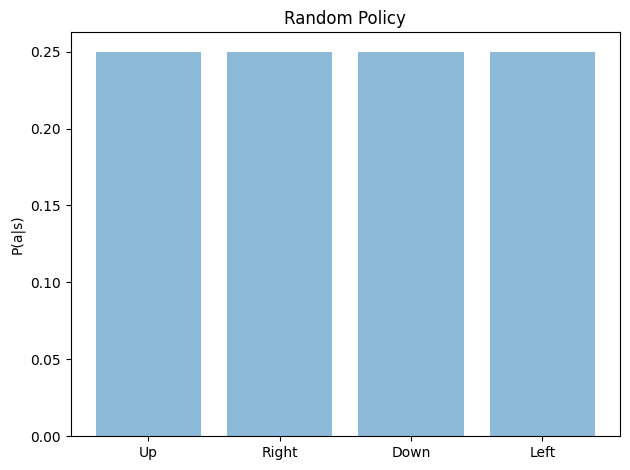

In [21]:
# Labels for the four actions, in order (index 0..3).
objects = ('Up', 'Right', 'Down', 'Left')
# Positions on the x-axis, one per action.
y_pos = np.arange(len(objects))

# Draw a bar for each action's probability.
plt.bar(y_pos, action_probabilities, alpha=0.5)
# Put the action names under the bars.
plt.xticks(y_pos, objects)
# Label the y-axis: probability of choosing each action.
plt.ylabel('P(a|s)')
# Give the chart a title.
plt.title('Random Policy')
# Tidy the spacing so labels are not cut off.
plt.tight_layout()

# Show the bar chart.
plt.show()

##### Use the policy to play an episode (This cell has been updated, read below)








In [22]:
# Run one full episode using a given policy and make a video of it.
def test_agent(environment, policy):
    # We will store one rendered picture per step to build the video.
    frames = []
    # Reset the maze and grab the first picture.
    state = env.reset()
    done = False
    frames.append(env.render(mode="rgb_array"))

    # Keep acting until the agent reaches the exit.
    while not done:
        # Ask the policy for the action probabilities in this state.
        action_probs = policy(state)
        # Randomly pick an action according to those probabilities.
        action = np.random.choice(range(4), 1, p=action_probs)
        # Apply the action and read the result.
        next_state, reward, done, extra_info = env.step(action)
        # Capture a picture of the new state and store it.
        img = env.render(mode="rgb_array")
        frames.append(img)
        # The landing square becomes the current square.
        state = next_state

    # Turn the stored frames into a playable video.
    return display_video(frames)


# Watch the random policy try to solve the maze.
test_agent(env, random_policy)